## Download the data
#### Source: _Yahoo Finance_

In [ ]:
from dataclasses import dataclass
from datetime import datetime
import pandas as pd
from typing import TypedDict
import yfinance as yf

@dataclass
class TickerHistory(TypedDict):
    name: str
    data: pd.DataFrame

def download_tickers_history(start_date: datetime, end_date: datetime, tickers: list[str]):   
    df_list = yf.download(
        tickers=tickers,
        start=start_date,
        end=end_date,
        interval="1d",
        group_by="ticker",
        auto_adjust=True,
        threads=True,
        progress=True
    );

    return df_list;

# set the date range for the historic data
start_date = datetime(year=2020, month=1, day=1)
end_date = datetime(year=2025, month=12, day=1)
history = download_tickers_history(start_date, end_date, ['NVDA', 'APPL']);


$APPL: possibly delisted; no price data found  (1d 2020-01-01 00:00:00 -> 2025-12-01 00:00:00)
[*********************100%***********************]  2 of 2 completed

1 Failed download:
['APPL']: possibly delisted; no price data found  (1d 2020-01-01 00:00:00 -> 2025-12-01 00:00:00)


## Basic data analytics

#### Returns
Working with raw prices (Close) is impossible in statistics, as they are non-stationary (the trend may be up or down, and the mathematical expectation may change over time). The first thing to do is to calculate the logarithmic return.

$$R_t = \ln(P_t / P_{t-1}) = \ln(P_t) - \ln(P_{t-1}),$$

where $t$ - time (day)

<>:33: SyntaxWarning: invalid escape sequence '\m'
<>:33: SyntaxWarning: invalid escape sequence '\s'
<>:33: SyntaxWarning: invalid escape sequence '\m'
<>:33: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Anton\AppData\Local\Temp\ipykernel_25424\1837294060.py:33: SyntaxWarning: invalid escape sequence '\m'
  label=f'Gauss distribution\n($\mu={mu:.4f}$, $\sigma={sigma:.4f}$)'
C:\Users\Anton\AppData\Local\Temp\ipykernel_25424\1837294060.py:33: SyntaxWarning: invalid escape sequence '\s'
  label=f'Gauss distribution\n($\mu={mu:.4f}$, $\sigma={sigma:.4f}$)'


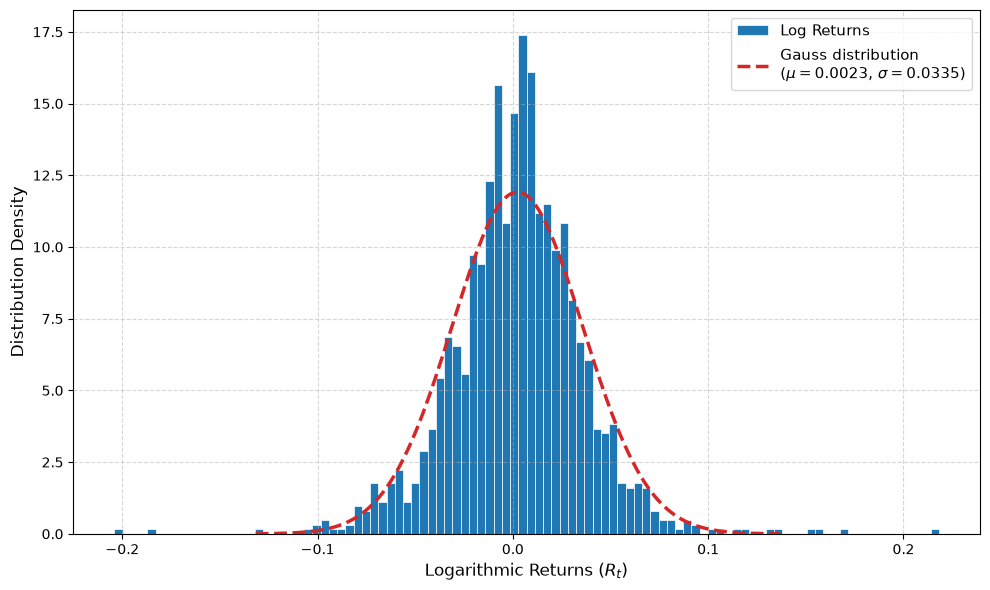

Skewness: 0.04475042984244752
Excess Kurtosis: 4.007301817055991


In [ ]:
import numpy as np;
import matplotlib.pyplot as plt;
from scipy.stats import norm

nvda = history.NVDA;
prices = nvda['Close'].to_numpy()
log_returns = np.diff(np.log(prices))

mu = np.mean(log_returns)
sigma = np.std(log_returns)

# data visualization
plt.figure(figsize=(10, 6))

_, bins, _ = plt.hist(
    log_returns, 
    density=True,
    bins=100,
    linewidth=0.5,
    edgecolor='w',
    label='Log Returns'
);

x = np.linspace(mu - 4*sigma, mu + 4*sigma, 500)
gauss = norm.pdf(x, loc=mu, scale=sigma)

plt.plot(
    x,
    gauss, 
    color='#d62728', 
    linewidth=2.5, 
    linestyle='--', 
    label=f'Gauss distribution\n($\mu={mu:.4f}$, $\sigma={sigma:.4f}$)'
)

plt.xlabel('Logarithmic Returns ($R_t$)', fontsize=12)
plt.ylabel('Distribution Density', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11)
plt.tight_layout()

plt.show();


### Find the distribution

We're gonna use some quantitative criteria (Skewness and Excess Kurtosis), and also test test the hypothesis that the observed sample of returns follows a normal distribution using two different criterias:
* Pirson (Сhi-square)
* Shapiro-Wilk test

In [41]:
from scipy.stats import skew, kurtosis

skewness = skew(log_returns)
excess_kurtosis = kurtosis(log_returns)

print("Skewness:", skewness)
print("Excess Kurtosis:", excess_kurtosis)

if skewness in [0.1, 0.5] or excess_kurtosis > 0:
    print("The distribution is likely NOT Normal.")
else:
    print("Looks like it is Normal distribution.")

Skewness: 0.04475042984244752
Excess Kurtosis: 4.007301817055991
The distribution is likely NOT Normal.


In [40]:
from scipy.stats import chisquare

# Normal with mu=0.0023 and sigme=0.0335
n = len(log_returns)

# split into intervals
num_bins = 20
observed_freq, bin_edges = np.histogram(log_returns, bins=num_bins)

# generate random 
cdf_values = norm.cdf(bin_edges, loc=mu, scale=sigma) # Gauss CDF
expected_prob = np.diff(cdf_values) # probability of falling into the i-th interval
expected_freq = expected_prob * n

expected_freq = expected_freq * (observed_freq.sum() / expected_freq.sum())

chi2_stat, p_value = chisquare(f_obs=observed_freq, f_exp=expected_freq, ddof=2)

print(f"Criterion statistics: {chi2_stat:.3f}")
print(f"P-value: {p_value:.3f}")

if p_value < 0.05:
    print("Hypothesis H0 is rejected: The distribution IS NOT Normal.")
else:
    print("Hypothesis H0 IS NOT rejected: Looks like it is Normal distribution.")


Criterion statistics: 396250.213
P-value: 0.000
Hypothesis H0 is rejected: The distribution IS NOT Normal.
